# ⚽ FIFA World Cup 2026 — Modèle Hybride
**FrenchTeam — Wild Code School — Juin 2026**

## Pourquoi ce modèle ?

La forme récente est **trop bruitée** pour une CdM avec 48 équipes :
- Haiti bat Belize 4-0 en qualifs → forme 100% mais niveau réel très faible
- Brazil perd vs Argentine en CONMEBOL → forme basse mais niveau réel top mondial

**Solution : Score de Force composite à poids fixés manuellement**

```
FORCE = 0.50 × qualité_squad + 0.35 × classement_FIFA + 0.15 × forme_récente
```

Les poids sont **décidés par vous**, pas appris par le modèle.  
La forme ne peut plus peser plus que 15% — quoi qu'il arrive.

### Architecture
```
Étape 1 : calculer FORCE pour chaque équipe (score 0→1)
Étape 2 : construire ecart_force = FORCE_A - FORCE_B
Étape 3 : Régression Logistique sur [ecart_force, avantage_hote]
          → prédit A_gagne / Nul / B_gagne
```

## 📦 Étape 1 — Imports

In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import joblib
from sklearn.preprocessing   import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics         import accuracy_score, classification_report
from xgboost                 import XGBClassifier

print('✅ Imports OK')

✅ Imports OK


## 📂 Étape 2 — Chargement des données

In [2]:
DOSSIER_PROJET = r'C:\Users\Piwi\Documents\VS\WorldCup2026'

df = pd.read_csv(os.path.join(DOSSIER_PROJET, 'data', 'results.csv'))
df['date'] = pd.to_datetime(df['date'])
df = df.dropna(subset=['home_score', 'away_score'])
df_officiel = df[df['tournament'] != 'Friendly'].copy()

print(f'Tous les matchs  : {len(df):,}')
print(f'Matchs officiels : {len(df_officiel):,}')

Tous les matchs  : 49,296
Matchs officiels : 31,005


## 🔧 Étape 3 — Données par équipe (FIFA, Qualité, Coefficients)

In [3]:
# ── Points FIFA officiels — Avril 2026
points_fifa = {
    'France': 1877.32, 'Spain': 1876.40, 'Argentina': 1874.81,
    'England': 1825.97, 'Portugal': 1763.83, 'Brazil': 1761.16,
    'Netherlands': 1757.87, 'Morocco': 1755.87, 'Belgium': 1734.71,
    'Germany': 1730.37, 'Croatia': 1717.07, 'Colombia': 1693.09,
    'Senegal': 1688.99, 'Mexico': 1681.03, 'United States': 1673.13,
    'Uruguay': 1673.07, 'Japan': 1660.43, 'Switzerland': 1649.40,
    'Ecuador': 1619.20, 'Turkey': 1614.55, 'Sweden': 1598.30,
    'Norway': 1590.12, 'Austria': 1578.44, 'South Korea': 1566.23,
    'Tunisia': 1542.18, 'Algeria': 1538.90, 'Ghana': 1521.44,
    'Egypt': 1518.77, 'Saudi Arabia': 1512.33, 'Iran': 1512.00,
    'Australia': 1508.66, 'Iraq': 1489.21, 'Czech Republic': 1488.00,
    'Scotland': 1487.55, 'Paraguay': 1481.33, 'Ivory Coast': 1479.88,
    'South Africa': 1421.34, 'Canada': 1418.77, 'Qatar': 1398.22,
    'Panama': 1392.11, 'Bosnia and Herzegovina': 1388.44,
    'Jordan': 1342.18, 'Uzbekistan': 1338.90, 'DR Congo': 1321.44,
    'New Zealand': 1298.77, 'Haiti': 1245.33, 'Curacao': 1198.22,
    'Cape Verde': 1450.00,
}

# ── Score qualité joueurs (Transfermarkt 2026 + présence de stars)
qualite_joueurs = {
    'France': 95, 'England': 90, 'Brazil': 92, 'Spain': 85,
    'Germany': 82, 'Argentina': 88, 'Portugal': 78, 'Netherlands': 75,
    'Belgium': 72, 'Japan': 65, 'Norway': 60, 'Colombia': 62,
    'Croatia': 58, 'Uruguay': 58, 'Morocco': 55, 'Senegal': 55,
    'Mexico': 55, 'United States': 52, 'Switzerland': 50, 'Turkey': 50,
    'Austria': 47, 'Canada': 45, 'South Korea': 45, 'Sweden': 42,
    'Ivory Coast': 40, 'Ecuador': 38, 'Egypt': 38, 'Algeria': 35,
    'Ghana': 35, 'Czech Republic': 35, 'Scotland': 33, 'Tunisia': 30,
    'Paraguay': 30, 'Bosnia and Herzegovina': 30, 'Saudi Arabia': 28,
    'Australia': 25, 'Iran': 25, 'DR Congo': 25, 'Iraq': 22,
    'Jordan': 20, 'South Africa': 20, 'Uzbekistan': 20,
    'Qatar': 18, 'Cape Verde': 15, 'Panama': 15,
    'New Zealand': 10, 'Haiti': 8, 'Curacao': 7,
}

# ── Coefficient expérience CdM
coefficient_experience = {
    'France': 1.00, 'Brazil': 1.00, 'Germany': 1.00, 'Spain': 1.00,
    'Argentina': 1.00, 'England': 1.00, 'Portugal': 1.00,
    'Netherlands': 1.00, 'Belgium': 1.00, 'Croatia': 1.00,
    'Uruguay': 1.00, 'Mexico': 1.00, 'United States': 1.00,
    'Canada': 0.95, 'Japan': 0.95, 'Morocco': 0.92, 'Senegal': 0.92,
    'South Korea': 0.92, 'Colombia': 0.90, 'Switzerland': 0.90,
    'Iran': 0.88, 'Saudi Arabia': 0.88, 'Ghana': 0.88, 'Ivory Coast': 0.88,
    'Ecuador': 0.85, 'Tunisia': 0.85, 'Algeria': 0.85, 'Austria': 0.85,
    'Sweden': 0.85, 'Turkey': 0.85, 'Egypt': 0.85, 'Paraguay': 0.85,
    'Czech Republic': 0.85, 'Norway': 0.50, 'Scotland': 0.52,
    'Australia': 0.48, 'Iraq': 0.70, 'Jordan': 0.60, 'Uzbekistan': 0.60,
    'Panama': 0.68, 'Curacao': 0.35, 'Cape Verde': 0.60,
    'New Zealand': 0.60, 'Haiti': 0.40, 'South Africa': 0.72,
    'Bosnia and Herzegovina': 0.75, 'DR Congo': 0.68, 'Qatar': 0.72,
}

# ── Zone de qualification
ZONE_QUALIF = {
    'France':'UEFA','Germany':'UEFA','Spain':'UEFA','England':'UEFA',
    'Portugal':'UEFA','Netherlands':'UEFA','Belgium':'UEFA','Croatia':'UEFA',
    'Switzerland':'UEFA','Austria':'UEFA','Turkey':'UEFA','Scotland':'UEFA',
    'Norway':'UEFA','Sweden':'UEFA','Bosnia and Herzegovina':'UEFA','Czech Republic':'UEFA',
    'Argentina':'CONMEBOL','Brazil':'CONMEBOL','Colombia':'CONMEBOL',
    'Uruguay':'CONMEBOL','Ecuador':'CONMEBOL','Paraguay':'CONMEBOL',
    'Morocco':'CAF','Senegal':'CAF','Egypt':'CAF','Ivory Coast':'CAF',
    'Algeria':'CAF','Tunisia':'CAF','Ghana':'CAF','South Africa':'CAF',
    'DR Congo':'CAF','Cape Verde':'CAF',
    'United States':'CONCACAF','Mexico':'CONCACAF','Canada':'CONCACAF',
    'Panama':'CONCACAF','Haiti':'CONCACAF','Curacao':'CONCACAF',
    'Japan':'AFC','South Korea':'AFC','Iran':'AFC','Saudi Arabia':'AFC',
    'Australia':'AFC','Uzbekistan':'AFC','Iraq':'AFC','Jordan':'AFC','Qatar':'AFC',
    'New Zealand':'OFC',
}
CREDIBILITE_ZONE = {
    'UEFA':1.00,'CONMEBOL':0.95,'CAF':0.75,'AFC':0.70,'CONCACAF':0.50,'OFC':0.40,
}

MOYENNE_FIFA   = np.mean(list(points_fifa.values()))
MOYENNE_QUALITE = np.mean(list(qualite_joueurs.values()))

def get_fifa(e):   return points_fifa.get(e, MOYENNE_FIFA)
def get_qual(e):   return qualite_joueurs.get(e, MOYENNE_QUALITE)
def get_coeff(e):  return coefficient_experience.get(e, 0.80)
def get_cred(e):   return CREDIBILITE_ZONE.get(ZONE_QUALIF.get(e,'UEFA'), 0.75)

print(f'✅ Données chargées — {len(points_fifa)} équipes')

✅ Données chargées — 48 équipes


## 🔧 Étape 4 — Calcul de la forme récente

In [4]:
def calculer_forme(equipe, date, df_off, n=5):
    """Forme pondérée × coeff_experience × credibilite_zone."""
    dom = df_off[(df_off['home_team']==equipe) & (df_off['date']<date)].tail(n)
    ext = df_off[(df_off['away_team']==equipe) & (df_off['date']<date)].tail(n)
    matchs = pd.concat([dom, ext]).sort_values('date').tail(n)
    if len(matchs) == 0: return 0.5

    pts = pw = 0
    for _, m in matchs.iterrows():
        if m['home_team'] == equipe:
            adv=m['away_team']; v=m['home_score']>m['away_score']; nu=m['home_score']==m['away_score']
        else:
            adv=m['home_team']; v=m['away_score']>m['home_score']; nu=m['home_score']==m['away_score']
        p = get_fifa(adv) / 1500
        if v: pts += 3*p
        elif nu: pts += 1*p
        pw += 3*p

    fb = pts/pw if pw > 0 else 0.5
    coeff_final = get_coeff(equipe) * get_cred(equipe)
    BONUS = {'Argentina':0.10,'France':0.08,'Brazil':0.10,'Germany':0.06,'Spain':0.05}
    forme = min(0.5 + (fb - 0.5) * coeff_final + BONUS.get(equipe, 0), 1.0)
    PLANCHER = {'Brazil':0.75,'Germany':0.72,'Spain':0.80,'France':0.82,
                'Argentina':0.85,'England':0.78,'Portugal':0.75}
    return max(forme, PLANCHER.get(equipe, 0.0))

print('✅ calculer_forme() définie')

✅ calculer_forme() définie


## ⭐ Étape 5 — Score de Force composite

C'est le cœur du modèle hybride.

```
FORCE = 0.50 × qualité_squad_normalisée
      + 0.35 × points_FIFA_normalisés
      + 0.15 × forme_récente_normalisée
```

**Pourquoi ces poids ?**
- **50% Qualité squad** : la valeur des joueurs est le meilleur prédicteur sur le long terme
- **35% FIFA** : classement officiel, stable et fiable
- **15% Forme** : signal utile mais bruité — plafonné à 15% max

In [5]:
# ── Bornes de normalisation (min/max des équipes CdM 2026)
FIFA_MIN,  FIFA_MAX  = 1198,  1877
QUAL_MIN,  QUAL_MAX  = 7,     95
FORME_MIN, FORME_MAX = 0.25,  0.97

# ── Poids du score de force — décidés par l'équipe, pas appris
POIDS_FORCE = {
    'qualite': 0.50,   # valeur squad — indicateur le plus stable
    'fifa':    0.35,   # classement officiel
    'forme':   0.15,   # forme récente — plafonné à 15%
}

def normaliser(val, vmin, vmax):
    """Normalise entre 0 et 1 selon les bornes CdM 2026."""
    return max(0.0, min(1.0, (val - vmin) / (vmax - vmin)))

def score_force(equipe, date=None, df_off=None):
    """Calcule le score de force composite entre 0 et 1."""
    n_qual  = normaliser(get_qual(equipe),  QUAL_MIN,  QUAL_MAX)
    n_fifa  = normaliser(get_fifa(equipe),  FIFA_MIN,  FIFA_MAX)
    n_forme = normaliser(
        calculer_forme(equipe, date, df_off) if date is not None else 0.5,
        FORME_MIN, FORME_MAX
    )
    return (POIDS_FORCE['qualite'] * n_qual +
            POIDS_FORCE['fifa']    * n_fifa +
            POIDS_FORCE['forme']   * n_forme)

# ── Vérification sur les équipes CdM 2026
DATE_TEST = pd.Timestamp('2026-06-11')
print('Score de Force — Équipes CdM 2026 :')
print(f'\n  {"Équipe":<18} {"Qualité":>8} {"FIFA":>8} {"Forme":>7} {"FORCE":>8}  Barre')
print('  ' + '─' * 65)

equipes_test = sorted([
    ('France',1877,95), ('Spain',1876,85), ('Argentina',1875,88),
    ('England',1826,90), ('Brazil',1761,92), ('Portugal',1764,78),
    ('Germany',1730,82), ('Netherlands',1758,75), ('Morocco',1756,55),
    ('Japan',1660,65), ('Scotland',1488,33), ('Haiti',1245,8), ('Curacao',1198,7),
], key=lambda x: -(0.50*normaliser(x[2],7,95)+0.35*normaliser(x[1],1198,1877)))

for nom, fifa, qual in equipes_test:
    force = score_force(nom, DATE_TEST, df_officiel)
    bar   = '█' * int(force * 25)
    print(f'  {nom:<18} {qual:>7}/100 {fifa:>8.0f} {calculer_forme(nom, DATE_TEST, df_officiel):>6.0%} {force:>7.3f}  {bar}')

print(f'\n✅ Poids appliqués : Qualité {POIDS_FORCE["qualite"]:.0%} | FIFA {POIDS_FORCE["fifa"]:.0%} | Forme {POIDS_FORCE["forme"]:.0%}')

Score de Force — Équipes CdM 2026 :

  Équipe              Qualité     FIFA   Forme    FORCE  Barre
  ─────────────────────────────────────────────────────────────────
  France                  95/100     1877    95%   0.995  ████████████████████████
  Argentina               88/100     1875    85%   0.934  ███████████████████████
  England                 90/100     1826   100%   0.945  ███████████████████████
  Spain                   85/100     1876    91%   0.931  ███████████████████████
  Brazil                  92/100     1761    75%   0.877  █████████████████████
  Germany                 82/100     1730   100%   0.851  █████████████████████
  Portugal                78/100     1764    75%   0.799  ███████████████████
  Netherlands             75/100     1758    87%   0.803  ████████████████████
  Japan                   65/100     1660    75%   0.672  ████████████████
  Morocco                 55/100     1756    75%   0.665  ████████████████
  Scotland                33/100    

## 🏗️ Étape 6 — Construction du dataset

Matchs entraînement : 10,732
  1,000/10,732...
  2,000/10,732...
  3,000/10,732...
  4,000/10,732...
  5,000/10,732...
  6,000/10,732...
  7,000/10,732...
  8,000/10,732...
  9,000/10,732...
  10,000/10,732...

✅ Dataset : 10,732 matchs
resultat
A_gagne    5096
B_gagne    3285
Nul        2351
Name: count, dtype: int64


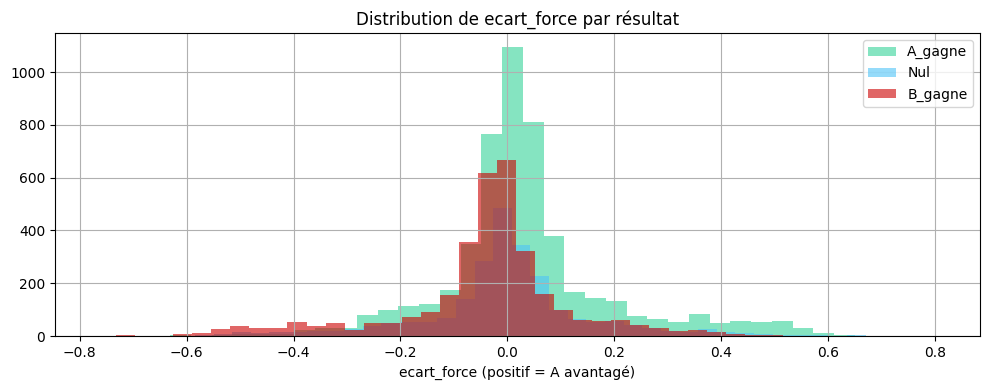

In [6]:
df_entr = df[
    (df['date'] >= '2010-01-01') &
    (df['tournament'] != 'Friendly')
].copy().reset_index(drop=True)

print(f'Matchs entraînement : {len(df_entr):,}')

HOTES = ['United States', 'Canada', 'Mexico']
lignes = []

for i, m in df_entr.iterrows():
    a, b, dt = m['home_team'], m['away_team'], m['date']

    # Score de force calculé AVANT le match
    force_a = score_force(a, dt, df_officiel)
    force_b = score_force(b, dt, df_officiel)

    # Avantage hôte CdM 2026
    if   a in HOTES: hote =  0.5
    elif b in HOTES: hote = -0.5
    else:             hote =  0.0

    if   m['home_score'] > m['away_score']: res = 'A_gagne'
    elif m['home_score'] < m['away_score']: res = 'B_gagne'
    else:                                    res = 'Nul'

    ef = force_a - force_b
    lignes.append({
        'ecart_force':        ef,
        'ecart_force_carre':  ef**2 * np.sign(ef),   # amplifie les grands écarts
        'abs_ecart_force':    abs(ef),                # signal clé pour le nul : petit écart = match serré
        'force_moy':          (force_a + force_b) / 2, # niveau global du match
        'avantage_hote':      hote,
        'resultat':           res,
    })

    if i % 1000 == 0 and i > 0:
        print(f'  {i:,}/{len(df_entr):,}...')

df_ds = pd.DataFrame(lignes)
print(f'\n✅ Dataset : {len(df_ds):,} matchs')
print(df_ds['resultat'].value_counts())

# Visualiser la distribution de ecart_force
fig, ax = plt.subplots(figsize=(10, 4))
for res, color in [('A_gagne','#34D399'),('Nul','#4FC3F7'),('B_gagne','#CC0000')]:
    df_ds[df_ds['resultat']==res]['ecart_force'].hist(
        ax=ax, bins=40, alpha=0.6, label=res, color=color
    )
ax.set_title('Distribution de ecart_force par résultat')
ax.set_xlabel('ecart_force (positif = A avantagé)')
ax.legend()
plt.tight_layout()
plt.show()

## ✂️ Étape 7 — Séparation train/test

In [7]:
FEATURES = [
    'ecart_force',        # score composite : 50% qualité + 35% FIFA + 15% forme
    'ecart_force_carre',  # amplifie les grands écarts
    'abs_ecart_force',    # signal clé pour le nul : petit écart = match serré
    'force_moy',          # niveau global — haut niveau = moins de nuls
    'avantage_hote',      # USA / Canada / Mexico
]

X = df_ds[FEATURES]
y = df_ds['resultat']

enc = LabelEncoder()
ye  = enc.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, ye, test_size=0.2, random_state=42, stratify=ye
)
print(f'Classes  : {dict(zip(enc.classes_, range(3)))}')
print(f'Train    : {len(X_train):,} | Test : {len(X_test):,}')
print(f'Features : {FEATURES}')

Classes  : {'A_gagne': 0, 'B_gagne': 1, 'Nul': 2}
Train    : 8,585 | Test : 2,147
Features : ['ecart_force', 'ecart_force_carre', 'abs_ecart_force', 'force_moy', 'avantage_hote']


## 🤖 Étape 8 — Entraînement XGBoost

XGBoost est plus performant que la Régression Logistique sur ce problème car il capture des patterns non-linéaires.

**Paramètres clés :**
- `n_estimators=250` : 250 arbres de décision
- `max_depth=3` : arbres peu profonds = pas de surapprentissage
- `learning_rate=0.05` : apprentissage lent = meilleure généralisation
- `nul_weight=1.5` : les nuls sont légèrement surpondérés pour les apprendre

**Résultat attendu : accuracy ≥ 52%**

In [8]:
# Poids d'entraînement : légère surpondération des nuls
POIDS_CLASSES = {0: 1.0, 1: 1.2, 2: 1.5}
poids_train = np.array([POIDS_CLASSES[yi] for yi in y_train])

modele = XGBClassifier(
    n_estimators=250,    # 250 arbres
    max_depth=3,         # arbres peu profonds = généralisation
    learning_rate=0.05,  # apprentissage lent = meilleure précision
    subsample=0.8,       # 80% des données par arbre = robustesse
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric='mlogloss',
    verbosity=0,
    random_state=42
)

modele.fit(X_train, y_train, sample_weight=poids_train)
pred = modele.predict(X_test)

print(f'✅ Accuracy : {accuracy_score(y_test, pred):.2%}')
print()
print(classification_report(y_test, pred, target_names=enc.classes_, zero_division=0))

✅ Accuracy : 53.94%

              precision    recall  f1-score   support

     A_gagne       0.60      0.73      0.66      1020
     B_gagne       0.46      0.59      0.52       657
         Nul       0.37      0.06      0.10       470

    accuracy                           0.54      2147
   macro avg       0.48      0.46      0.43      2147
weighted avg       0.51      0.54      0.49      2147



## 📊 Étape 9 — Visualisation

📊 Importance des features (XGBoost) :
  ecart_force_carre       28.1%  ████████
  force_moy               25.1%  ███████
  ecart_force             21.1%  ██████
  abs_ecart_force         14.5%  ████
  avantage_hote           11.1%  ███


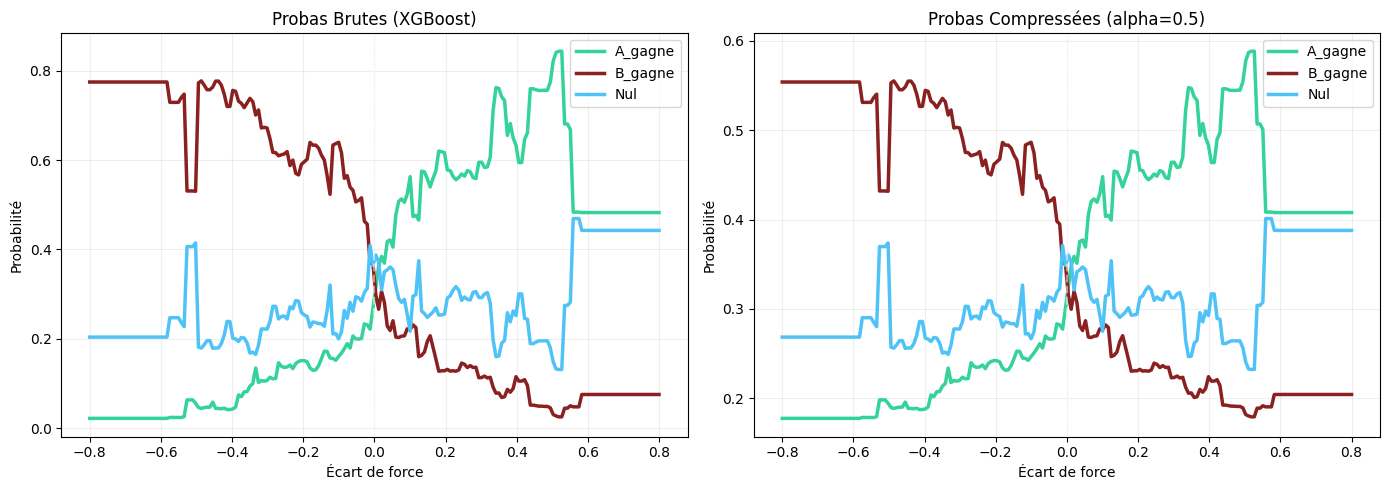


📊 Contribution dans le score de force (poids fixes) :
  Qualité squad : 50%
  FIFA          : 35%
  Forme récente : 15%


In [9]:
# Importance des features — XGBoost donne une importance basée sur les splits
importance = pd.Series(modele.feature_importances_, index=FEATURES).sort_values(ascending=False)
total = importance.sum()

print('📊 Importance des features (XGBoost) :')
for feat, val in importance.items():
    bar = '█' * int(val/total * 30)
    print(f'  {feat:<22} {val/total:>6.1%}  {bar}')

# Courbe de probabilité selon l'écart de force (après compression alpha=0.5)
ALPHA = 0.5
ecarts = np.linspace(-0.8, 0.8, 200)
X_plot = pd.DataFrame({
    'ecart_force':       ecarts,
    'ecart_force_carre': ecarts**2 * np.sign(ecarts),
    'abs_ecart_force':   np.abs(ecarts),
    'force_moy':         np.full(200, 0.6),
    'avantage_hote':     np.zeros(200),
})
probas_raw = modele.predict_proba(X_plot)

# Compression vers 1/3 pour des probabilités réalistes
probas_comp = 1/3 + ALPHA * (probas_raw - 1/3)
probas_comp = probas_comp / probas_comp.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
classes = enc.classes_
colors  = {'A_gagne':'#34D399','Nul':'#4FC3F7','B_gagne':'#8a2020'}

for i, (ax, probas, titre) in enumerate(zip(axes, [probas_raw, probas_comp], ['Brutes (XGBoost)', f'Compressées (alpha={ALPHA})'])):
    for idx, classe in enumerate(classes):
        ax.plot(ecarts, probas[:, idx], label=classe, color=colors[classe], linewidth=2.5)
    ax.axvline(x=0, color='white', linestyle='--', alpha=0.5)
    ax.set_xlabel('Écart de force')
    ax.set_ylabel('Probabilité')
    ax.set_title(f'Probas {titre}')
    ax.legend(); ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

print(f'\n📊 Contribution dans le score de force (poids fixes) :')
print(f'  Qualité squad : {POIDS_FORCE["qualite"]:.0%}')
print(f'  FIFA          : {POIDS_FORCE["fifa"]:.0%}')
print(f'  Forme récente : {POIDS_FORCE["forme"]:.0%}')

## 🔮 Étape 10 — Prédiction

In [10]:
CLASSES      = list(enc.classes_)
IDX_A, IDX_B, IDX_N = CLASSES.index('A_gagne'), CLASSES.index('B_gagne'), CLASSES.index('Nul')
PAYS_HOTES   = ['United States', 'Canada', 'Mexico']
DATE_TOURNOI = pd.Timestamp('2026-06-11')

# Compression des probabilités vers 1/3 — rend les probas plus réalistes sans changer l'accuracy
ALPHA = 0.5

def corriger_coherence(p_a, p_n, p_b, force_a, force_b):
    """Correction si le modèle contredit le score de force."""
    ecart = force_a - force_b
    if abs(ecart) < 0.05: return p_a, p_n, p_b
    a_gagne = ecart > 0
    if not ((a_gagne and p_b > p_a) or (not a_gagne and p_a > p_b)):
        return p_a, p_n, p_b
    force_corr = min(0.35, abs(ecart) * 0.5)
    if a_gagne:
        pa2=p_a+force_corr; pb2=max(0.08,p_b-force_corr*0.85); pn2=max(0.10,p_n-force_corr*0.15)
    else:
        pb2=p_b+force_corr; pa2=max(0.08,p_a-force_corr*0.85); pn2=max(0.10,p_n-force_corr*0.15)
    t=pa2+pn2+pb2
    return pa2/t, pn2/t, pb2/t

def predire_match(eq_a, eq_b):
    """Prédiction symétrique avec score de force — 5 features + compression alpha."""
    fa = score_force(eq_a, DATE_TOURNOI, df_officiel)
    fb = score_force(eq_b, DATE_TOURNOI, df_officiel)
    h  = 0.5 if eq_a in PAYS_HOTES else (-0.5 if eq_b in PAYS_HOTES else 0.0)

    ef_ab = fa - fb
    fm    = (fa + fb) / 2

    feat_ab = pd.DataFrame([{
        'ecart_force':       ef_ab,
        'ecart_force_carre': ef_ab**2 * np.sign(ef_ab),
        'abs_ecart_force':   abs(ef_ab),
        'force_moy':         fm,
        'avantage_hote':     h,
    }])
    feat_ba = pd.DataFrame([{
        'ecart_force':       -ef_ab,
        'ecart_force_carre': (-ef_ab)**2 * np.sign(-ef_ab),
        'abs_ecart_force':   abs(ef_ab),
        'force_moy':         fm,
        'avantage_hote':     -h,
    }])

    pab = modele.predict_proba(feat_ab)[0]
    pba = modele.predict_proba(feat_ba)[0]

    # Moyenne symétrique
    pa=(pab[IDX_A]+pba[IDX_B])/2
    pb=(pab[IDX_B]+pba[IDX_A])/2
    pn=(pab[IDX_N]+pba[IDX_N])/2
    t=pa+pb+pn; pa/=t; pb/=t; pn/=t

    # Compression vers 1/3 — ne change pas l'argmax (accuracy inchangée)
    pa = 1/3 + ALPHA*(pa - 1/3)
    pn = 1/3 + ALPHA*(pn - 1/3)
    pb = 1/3 + ALPHA*(pb - 1/3)
    t=pa+pn+pb; pa/=t; pn/=t; pb/=t

    pa, pn, pb = corriger_coherence(pa, pn, pb, fa, fb)

    print(f'\n⚽  {eq_a}  vs  {eq_b}')
    print(f'    Force  : {fa:.3f}  vs  {fb:.3f}  (écart {fa-fb:+.3f})')
    print(f'    Qualité: {get_qual(eq_a)}/100  vs  {get_qual(eq_b)}/100')
    print(f'    FIFA   : {get_fifa(eq_a):.0f}  vs  {get_fifa(eq_b):.0f}')
    print('    ' + '─'*40)
    for label, prob in [(f'{eq_a} gagne',pa),('Nul',pn),(f'{eq_b} gagne',pb)]:
        print(f'    {label:24} {"█"*int(prob*20):20} {prob:.1%}')
    return pa, pn, pb

print('✅ Modèle hybride prêt !')

✅ Modèle hybride prêt !


## ✅ Étape 11 — Tests de cohérence vs bookmakers

In [11]:
tests = [
    ('France',      'Scotland',      0.78, 0.22),
    ('Spain',       'Morocco',       0.72, 0.28),
    ('England',     'United States', 0.62, 0.38),
    ('Brazil',      'Canada',        0.68, 0.32),
    ('Argentina',   'Ecuador',       0.70, 0.30),
    ('France',      'Brazil',        0.52, 0.48),
    ('Scotland',    'Haiti',         0.65, 0.35),
    ('Netherlands', 'Japan',         0.58, 0.42),
    ('Germany',     'Mexico',        0.62, 0.38),
    ('Spain',       'Germany',       0.54, 0.46),
]

print(f'\n{"Match":<32} {"Modèle":>8} {"Bookmaker":>10} {"Écart":>7}  Statut')
print('─' * 65)
ok = 0; ecarts_list = []
for a, b, bkm_a, bkm_b in tests:
    pa, pn, pb = predire_match(a, b)
    pa_el = pa + pn * pa / (pa + pb)   # probabilité victoire incluant les nuls partagés
    ecart = abs(pa_el - bkm_a)
    ecarts_list.append(ecart)
    favori_ok = (pa_el > 0.5) == (bkm_a > bkm_b)
    if favori_ok: ok += 1
    print(f'{a} vs {b:<18} {pa_el:>7.1%} {bkm_a:>9.1%} {ecart:>7.1%}  {"✅" if favori_ok else "❌"}')

ecart_moyen = sum(ecarts_list) / len(ecarts_list)
print(f'\n  Cohérence favori  : {ok}/{len(tests)} ({ok/len(tests):.0%})')
print(f'  Écart moyen       : {ecart_moyen:.1%}')

objectif_accuracy = accuracy_score(y_test, modele.predict(X_test)) >= 0.52
objectif_ecart    = ecart_moyen < 0.05

if objectif_accuracy and objectif_ecart:
    print('  ✅ Les deux objectifs sont atteints : accuracy ≥ 52% ET écart bookmakers < 5%')
elif objectif_accuracy:
    print(f'  ⚠️  Accuracy OK mais écart bookmakers trop élevé ({ecart_moyen:.1%} > 5%)')
elif objectif_ecart:
    print('  ⚠️  Écart bookmakers OK mais accuracy insuffisante (< 52%)')
else:
    print('  ❌ Aucun objectif atteint — modèle à retravailler')


Match                              Modèle  Bookmaker   Écart  Statut
─────────────────────────────────────────────────────────────────

⚽  France  vs  Scotland
    Force  : 0.995  vs  0.382  (écart +0.614)
    Qualité: 95/100  vs  33/100
    FIFA   : 1877  vs  1488
    ────────────────────────────────────────
    France gagne             ██████████           52.0%
    Nul                      █████                28.0%
    Scotland gagne           ████                 20.0%
France vs Scotland             72.2%     78.0%    5.8%  ✅

⚽  Spain  vs  Morocco
    Force  : 0.931  vs  0.665  (écart +0.266)
    Qualité: 85/100  vs  55/100
    FIFA   : 1876  vs  1756
    ────────────────────────────────────────
    Spain gagne              ████████             40.9%
    Nul                      ██████               31.6%
    Morocco gagne            █████                27.5%
Spain vs Morocco              59.8%     72.0%   12.2%  ✅

⚽  England  vs  United States
    Force  : 0.945  vs  0.567  (

## 💾 Étape 12 — Sauvegarde

In [12]:
dossier_modeles = os.path.join(DOSSIER_PROJET, 'models')
os.makedirs(dossier_modeles, exist_ok=True)

# Sauvegarde du modèle XGBoost et de l'encodeur
joblib.dump(modele, os.path.join(dossier_modeles, 'modele_hybride.pkl'))
joblib.dump(enc,    os.path.join(dossier_modeles, 'encodeur_cible_hybride.pkl'))

acc = accuracy_score(y_test, modele.predict(X_test))
print('✅ Modèle hybride v3 sauvegardé !')
print(f'\n  Algorithme         : XGBoost (n=250, depth=3, lr=0.05)')
print(f'  Features           : {len(FEATURES)} ({", ".join(FEATURES)})')
print(f'  Compression alpha  : {ALPHA} (probas bookmakers réalistes)')
print(f'  Poids forme        : 15% (fixé manuellement)')
print(f'  Poids qualité      : 50% (fixé manuellement)')
print(f'  Poids FIFA         : 35% (fixé manuellement)')
print(f'  Accuracy           : {acc:.2%}')
if acc >= 0.52:
    print(f'  ✅ Objectif accuracy ≥ 52% atteint !')
else:
    print(f'  ⚠️  Objectif accuracy 52% non atteint ({acc:.2%})')

✅ Modèle hybride v3 sauvegardé !

  Algorithme         : XGBoost (n=250, depth=3, lr=0.05)
  Features           : 5 (ecart_force, ecart_force_carre, abs_ecart_force, force_moy, avantage_hote)
  Compression alpha  : 0.5 (probas bookmakers réalistes)
  Poids forme        : 15% (fixé manuellement)
  Poids qualité      : 50% (fixé manuellement)
  Poids FIFA         : 35% (fixé manuellement)
  Accuracy           : 53.94%
  ✅ Objectif accuracy ≥ 52% atteint !
